<a href="https://colab.research.google.com/github/PravinV001/Python/blob/Class_N_Colab/Classification_Matrix_6_Apr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
!gdown 1_jZRFvpjElFBGyOO-_4Cv68-n2cDbNUn

Downloading...
From: https://drive.google.com/uc?id=1_jZRFvpjElFBGyOO-_4Cv68-n2cDbNUn
To: /content/pred_data.csv
100% 247k/247k [00:00<00:00, 86.6MB/s]


In [ ]:
data = pd.read_csv('pred_data.csv')

data.head()

,y,proba
0,0.0,0.281035
1,0.0,0.465152
2,0.0,0.352793
3,0.0,0.157818
4,0.0,0.276648


In [ ]:
def foo(x):
  if x > 0.5:
    return 1
  else:
    return 0

In [ ]:
data['y_pred'] = data['proba'].apply(foo)

In [ ]:
data['y_pred'] = data['proba'].apply(lambda x: 1 if x > 0.5 else 0)

In [ ]:
data['y'].value_counts()

,count
y,
0.0,10000
1.0,100


In [ ]:
data

,y,proba,y_pred
0,0.0,0.281035,0
1,0.0,0.465152,0
2,0.0,0.352793,0
3,0.0,0.157818,0
4,0.0,0.276648,0
...,...,...,...
10095,0.0,0.474401,0
10096,0.0,0.128403,0
10097,0.0,0.499331,0
10098,0.0,0.157616,0


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
conf_matrix = confusion_matrix(data.y, data.y_pred)

In [ ]:
conf_matrix

array([[9761,  239],
       [  45,   55]])

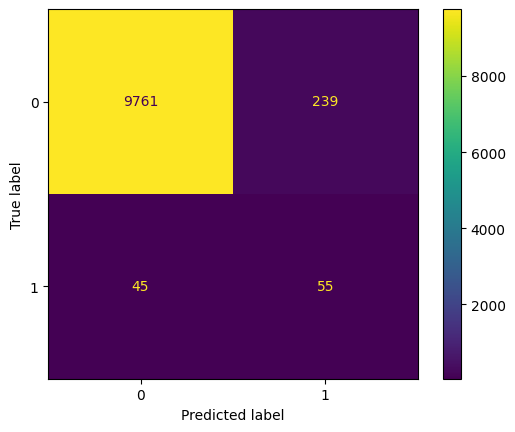

In [ ]:
ConfusionMatrixDisplay(conf_matrix).plot()

In [ ]:
tp = conf_matrix[1, 1]
tp

np.int64(55)

## Two new metrics

In [ ]:
y_pred = np.zeros(len(data.y)) # predictions of a dumb model
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

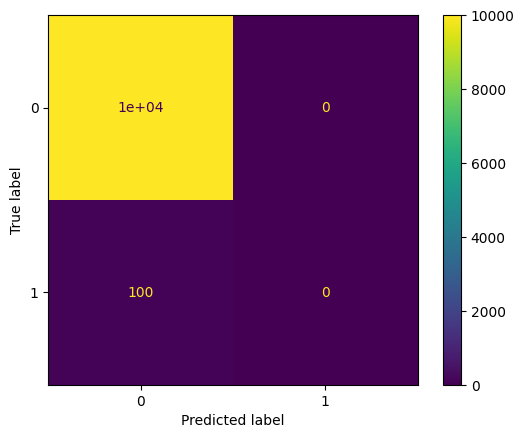

In [ ]:
conf_matrix = confusion_matrix(data.y, y_pred)
ConfusionMatrixDisplay(conf_matrix).plot()


In [ ]:
## tp/(tp+fp) - precision


## Recall = (tp/(tp + fn))

In [ ]:
from sklearn.metrics import recall_score


In [ ]:
recall_score(data.y, y_pred)


0.0

In [ ]:
recall_score(data.y, data.y_pred)


0.55

In [ ]:
from sklearn.metrics import precision_score


In [ ]:
## Dumb model
precision_score(data.y, y_pred)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.0

In [ ]:
precision_score(data.y, data.y_pred)

0.1870748299319728

## 10 :30

In [ ]:
!gdown 1O5fQvg0TsjH5uRlIHNxt-WByTg4SRfwI

Downloading...
From: https://drive.google.com/uc?id=1O5fQvg0TsjH5uRlIHNxt-WByTg4SRfwI
To: /content/pima-indians-diabetes (1).csv
100% 23.8k/23.8k [00:00<00:00, 3.30MB/s]


In [ ]:
import pandas as pd
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
pima = pd.read_csv('pima-indians-diabetes (1).csv', header=1, names=col_names)

In [ ]:
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


In [ ]:
# define X and y
feature_cols = ['pregnant','glucose', 'bp', 'skin', 'insulin', 'bmi', 'age']
X = pima[feature_cols]
y = pima.label

In [ ]:
## 10:35 pm

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y , random_state=1)

In [ ]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred_class = logreg.predict(X_test)

In [ ]:
y_pred_class

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [ ]:
# calculate accuracy
from sklearn import metrics
print(metrics.accuracy_score(y_test, y_pred_class))

0.7395833333333334


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm = metrics.confusion_matrix(y_test, y_pred_class)
plt.clf()

<Figure size 640x480 with 0 Axes>

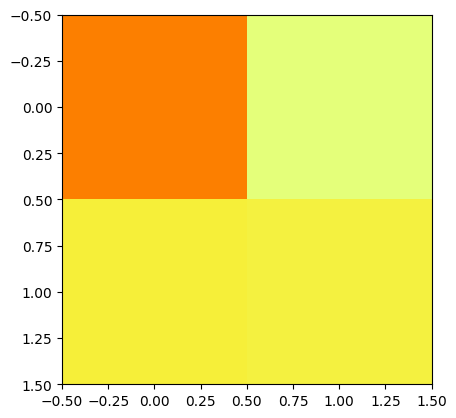

In [ ]:
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Wistia)

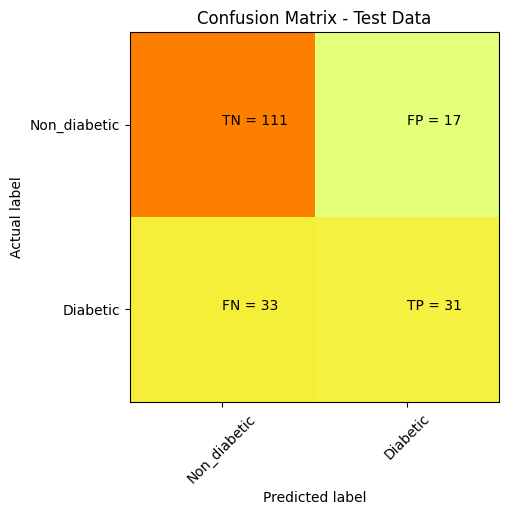

In [ ]:

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Wistia)
classNames = ['Non_diabetic','Diabetic']
plt.title('Confusion Matrix - Test Data')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['TN','FP'], ['FN', 'TP']]

for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()

In [ ]:
TP = 31
TN = 111
FP = 17
FN = 33

In [ ]:
print((TP + TN) / float(TP + TN + FP + FN))
print(metrics.accuracy_score(y_test, y_pred_class))

0.7395833333333334
0.7395833333333334


In [ ]:
print(TP / float(TP + FN))


print(metrics.recall_score(y_test, y_pred_class))

0.484375
0.484375


In [ ]:
print(TP / float(TP + FP))
print(metrics.precision_score(y_test, y_pred_class))

0.6458333333333334
0.6458333333333334


<img src='https://drive.google.com/uc?id=1f5J0tRMFioliW3rQ9JVE9Q9guuqle3bb'>

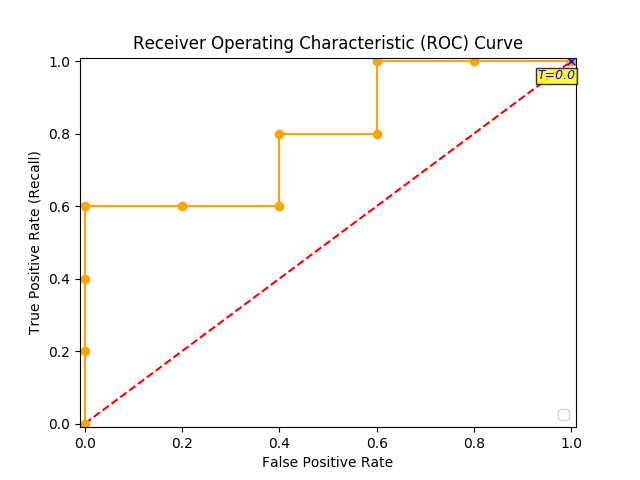

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
from matplotlib import pyplot as plt

In [ ]:
data

,y,proba,y_pred
0,0.0,0.281035,0
1,0.0,0.465152,0
2,0.0,0.352793,0
3,0.0,0.157818,0
4,0.0,0.276648,0
...,...,...,...
10095,0.0,0.474401,0
10096,0.0,0.128403,0
10097,0.0,0.499331,0
10098,0.0,0.157616,0


In [ ]:
fpr, tpr, thr = roc_curve(data.y, data.proba)

In [ ]:
list(zip(fpr, tpr, thr))[:5]

[(np.float64(0.0), np.float64(0.0), np.float64(inf)),
 (np.float64(0.0), np.float64(0.01), np.float64(0.5952941839776669)),
 (np.float64(0.0), np.float64(0.5), np.float64(0.510264685027965)),
 (np.float64(0.0005), np.float64(0.5), np.float64(0.5097239334789035)),
 (np.float64(0.0005), np.float64(0.51), np.float64(0.5096476105482314))]

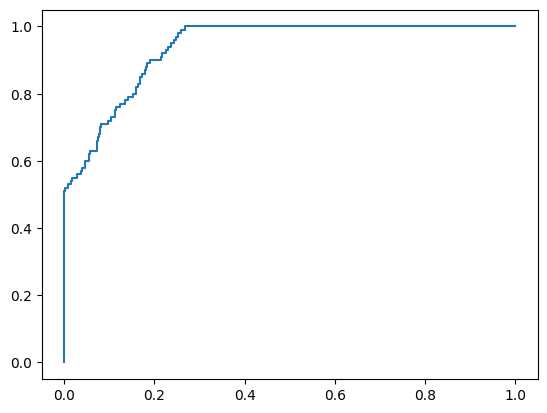

In [ ]:
plt.plot(fpr, from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, y_scores))

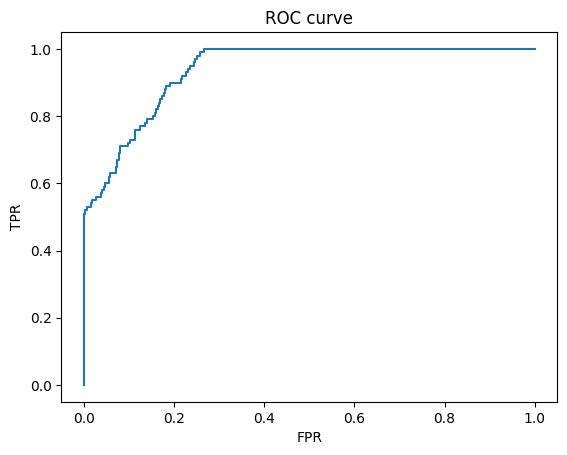

In [ ]:
plt.plot(fpr,tpr)
plt.title('ROC curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [ ]:
roc_auc_score(data.y, data.proba)

np.float64(0.9377570000000001)

## Precision Recall curve

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(data.y, data.proba)

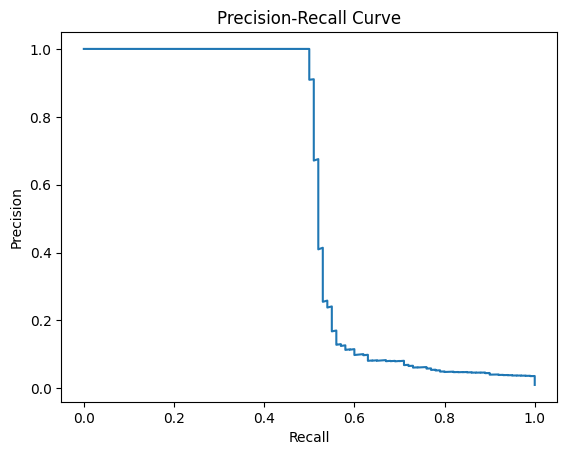

In [ ]:
## Recall improvement -- P(oos or not )


## Recall at precidsion

import matplotlib.pyplot as plt

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## Harmonic Mean

In [ ]:
## Mathematical - AM (a + b)//2

In [ ]:
## HM - 2ab/(a+b)

In [ ]:
## P is low and R is also low. thne HM punishes them more severely

In [ ]:
a = 0.3
b = 0.1

In [ ]:
AM = 0.5*(a+b)
AM

0.2

In [ ]:
HM = 2*a*b/(a+b)

In [ ]:
HM

0.15

## Case Study Homework

In [ ]:
# Let's say you were given 10,000 transaction data points:

# out of which 300 are fraudulent transactions
# The remaining 9700 are non-fraud



# You designed a model to classify a transaction as fraud or not.

# Let's say you have a confusion matrix like this.

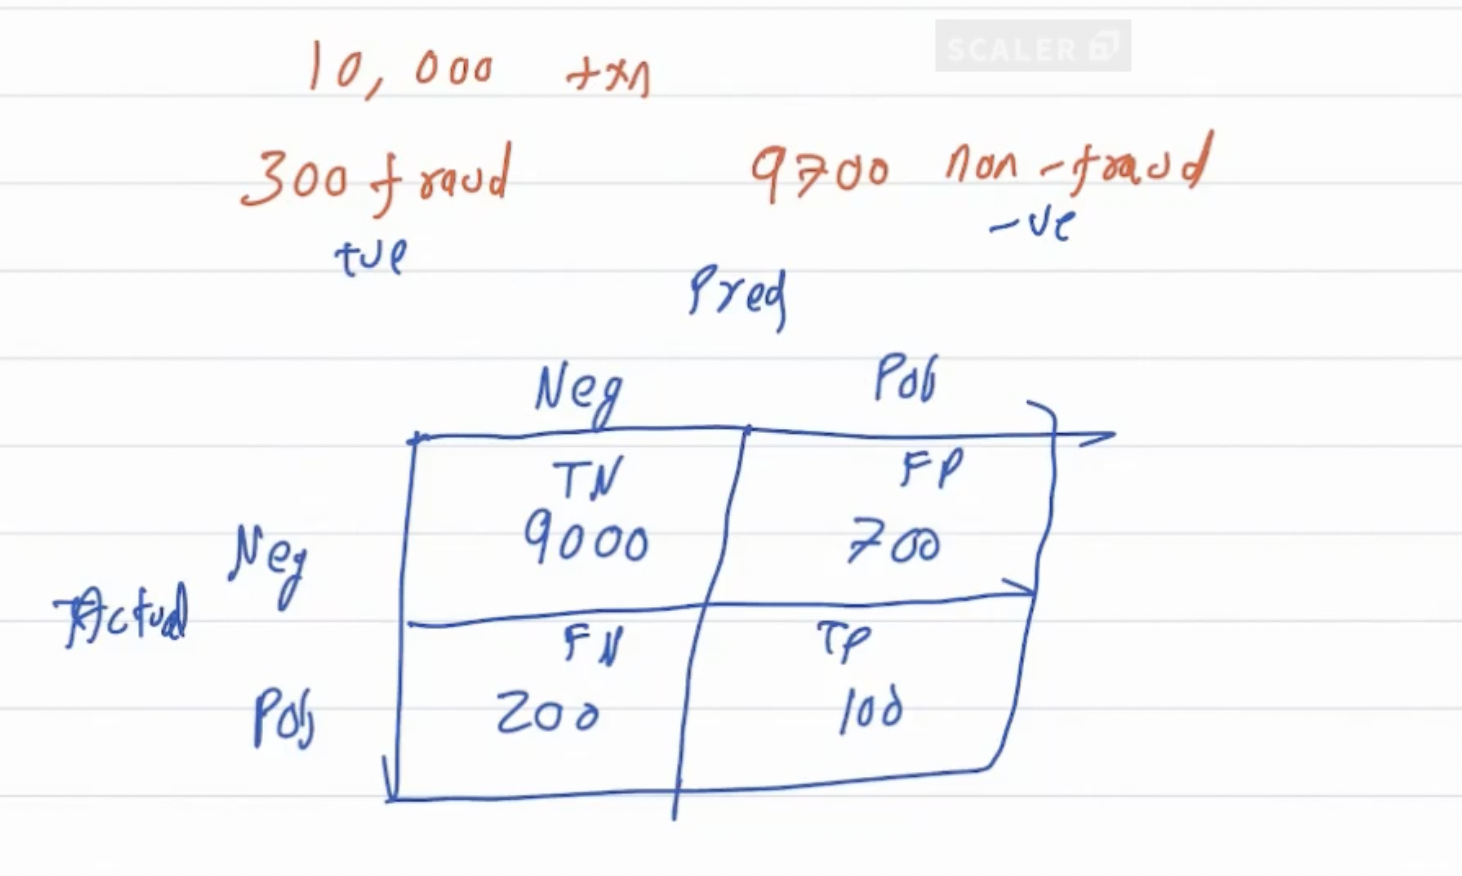

In [ ]:
## Find Precision, Recall, Accuracy, F1